# Instalación de librerias que nos permiten leer el archivo csv

In [1]:
# Instalar librerías necesarias
%pip install pandas matplotlib seaborn

# Importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


# Leemos el dataset, corregimos el formato y limpiamos los datos

In [2]:
# Cargar el dataset con el separador correcto
df = pd.read_csv("lung_disease_data2.csv", sep=";")

# Llenar valores nulos correctamente
df.update(df.select_dtypes(include=['number']).fillna(0))  # En columnas numéricas, reemplazar NaN con 0
df.update(df.select_dtypes(include=['object']).fillna("Desconocido"))  # En columnas de texto, usar "Desconocido"

# Eliminar espacios en blanco en columnas de texto
df[df.select_dtypes(include=['object']).columns] = df.select_dtypes(include=['object']).apply(lambda x: x.str.strip())

# Verificar que ya no haya valores nulos
print(df.isnull().sum())

# Ver valores únicos en columnas clave para asegurar que todo esté bien
print(df["Gender"].unique())
print(df["Smoking Status"].unique())
print(df["Disease Type"].unique())
print(df["Treatment Type"].unique())

Age                0
Gender             0
Smoking Status     0
Lung Capacity      0
Disease Type       0
Treatment Type     0
Hospital Visits    0
Recovered          0
dtype: int64
['Female' 'Male' 'Desconocido']
['No' 'Yes' 'Desconocido']
['COPD' 'Bronchitis' 'Asthma' 'Lung Cancer' 'Pneumonia' 'Desconocido']
['Therapy' 'Surgery' 'Desconocido' 'Medication']


# Exploramos los datos

- Comparativa de hombres y mujeres fumador@s
- Comparativa de gente que fuma y no fuma
- Comparativa de hombres y mujeres NO fumador@s

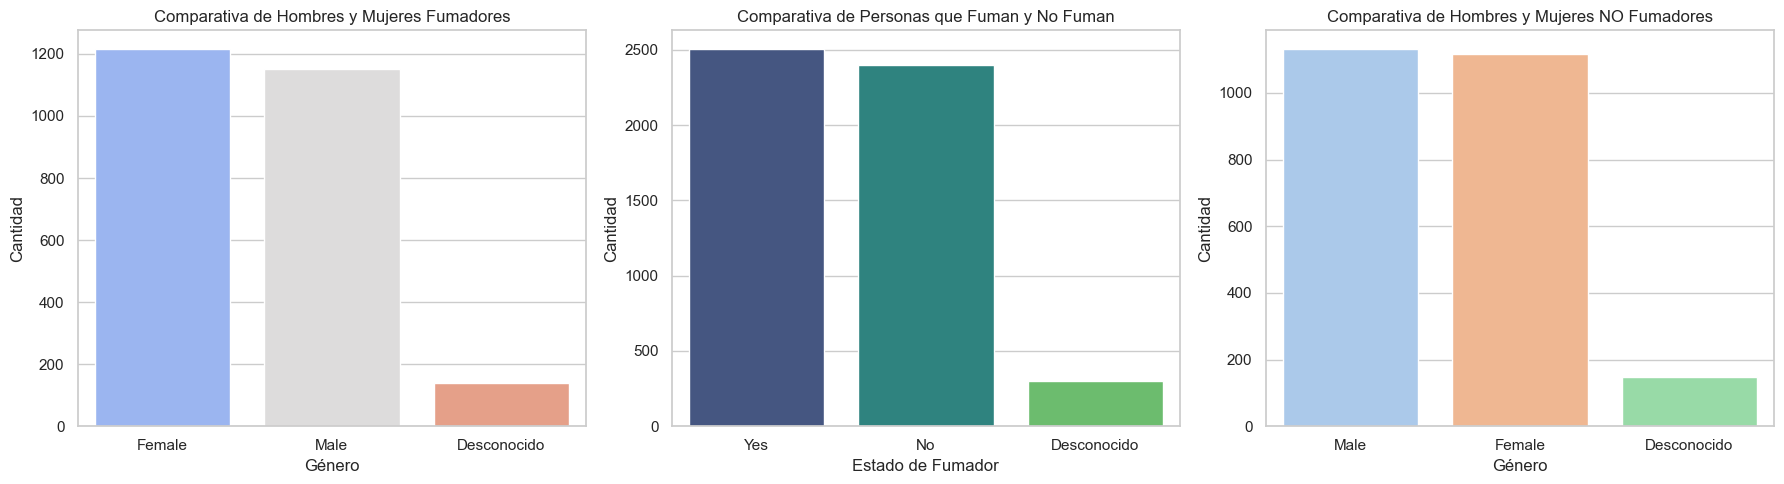

In [3]:
# Configuración del estilo de Seaborn (para que los colores queden calidos)
sns.set_theme(style="whitegrid")

# Creación de una figura con 3 subgráficos en una sola linea (figsize significa el tamaño que va a tener la figura (18 de ancho y 5 de alto))
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#Comparativa de hombres y mujeres fumadores
fumadores = df[df["Smoking Status"] == "Yes"]["Gender"].value_counts().reset_index()
sns.barplot(data=fumadores, x="Gender", y="count", hue="Gender", ax=axes[0], palette="coolwarm", legend=False)
axes[0].set_title("Comparativa de Hombres y Mujeres Fumadores")
axes[0].set_xlabel("Género")
axes[0].set_ylabel("Cantidad")

#Comparativa de gente que fuma y no fuma
fumadores_total = df["Smoking Status"].value_counts().reset_index()
sns.barplot(data=fumadores_total, x="Smoking Status", y="count", hue="Smoking Status", ax=axes[1], palette="viridis", legend=False)
axes[1].set_title("Comparativa de Personas que Fuman y No Fuman")
axes[1].set_xlabel("Estado de Fumador")
axes[1].set_ylabel("Cantidad")

#Comparativa de hombres y mujeres NO fumadores
no_fumadores = df[df["Smoking Status"] == "No"]["Gender"].value_counts().reset_index()
sns.barplot(data=no_fumadores, x="Gender", y="count", hue="Gender", ax=axes[2], palette="pastel", legend=False)
axes[2].set_title("Comparativa de Hombres y Mujeres NO Fumadores")
axes[2].set_xlabel("Género")
axes[2].set_ylabel("Cantidad")

# Ajustar el layout para evitar superposiciones
plt.tight_layout()
plt.show()

# cantidad de enfermos de las personas que fuman

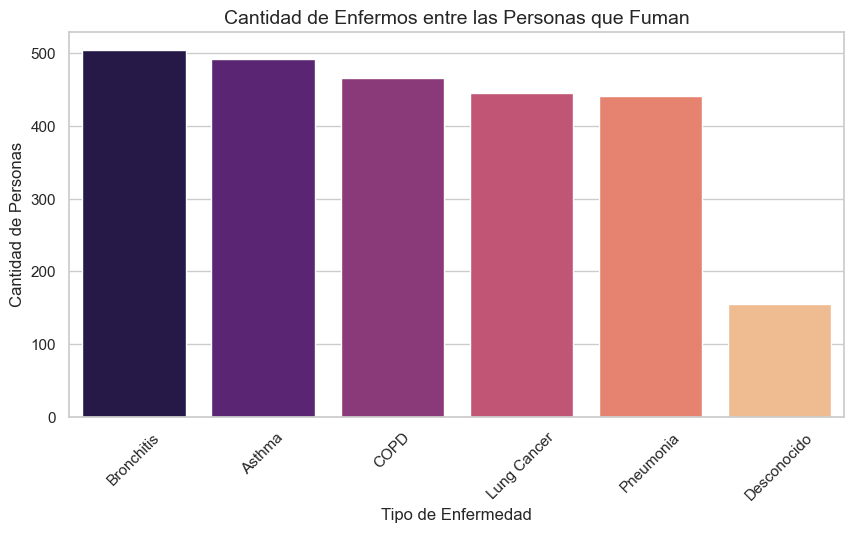

In [4]:
sns.set_theme(style="whitegrid")  # Fondo con cuadrícula

# Filtramos los datos solo para fumadores
fumadores_enfermos = df[df["Smoking Status"] == "Yes"]["Disease Type"].value_counts().reset_index()
fumadores_enfermos.columns = ["Disease Type", "count"]  # Renombramos columnas

# Creamos la gráfica de columnas
plt.figure(figsize=(10, 5))
sns.barplot(
    data=fumadores_enfermos,
    x="Disease Type",
    y="count",
    hue="Disease Type",   # paleta de colores para asignar colores unicos a cada enfermedad
    palette="magma",
    legend=False
)

# Agregamos títulos y etiquetas
plt.title("Cantidad de Enfermos entre las Personas que Fuman", fontsize=14)
plt.xlabel("Tipo de Enfermedad", fontsize=12)
plt.ylabel("Cantidad de Personas", fontsize=12)

# Rotamos etiquetas del eje X para que sean legibles
plt.xticks(rotation=45)
plt.show()

# Cantidad de visitas al hospital (por genero y enfermedades)

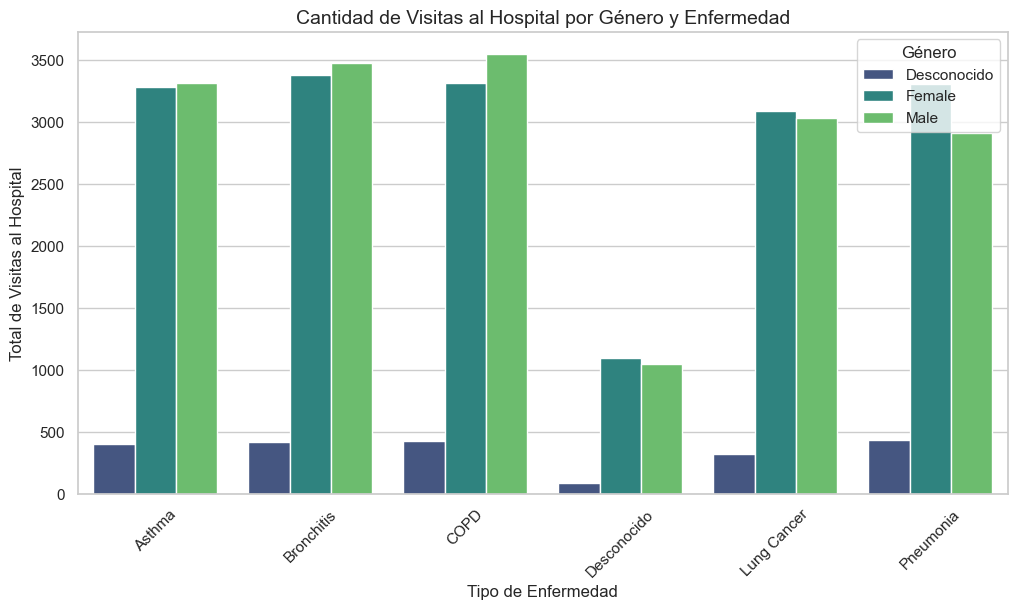

In [5]:
# Agrupamos los datos por genero y tipo de enfermedad, Luego sumamos todas las visitas al hospital por cada combinación.
hospital_visits = df.groupby(["Gender", "Disease Type"])["Hospital Visits"].sum().reset_index()

# Creamos la grafica
plt.figure(figsize=(12, 6))
sns.barplot(
    data=hospital_visits,
    x="Disease Type",
    y="Hospital Visits",
    hue="Gender",
    palette="viridis"
)

# Agregamos titulos y etiquetas
plt.title("Cantidad de Visitas al Hospital por Género y Enfermedad", fontsize=14)
plt.xlabel("Tipo de Enfermedad", fontsize=12)
plt.ylabel("Total de Visitas al Hospital", fontsize=12)

# Mejoramos la legibilidad
plt.xticks(rotation=45)
plt.legend(title="Género")
plt.show()

# Hombres y Mujeres por Enfermedades (Fumadores y No Fumadores)

Este requerimiento implica dos gráficos separados:
- Fumadores por enfermedad y género
- No fumadores por enfermedad y género

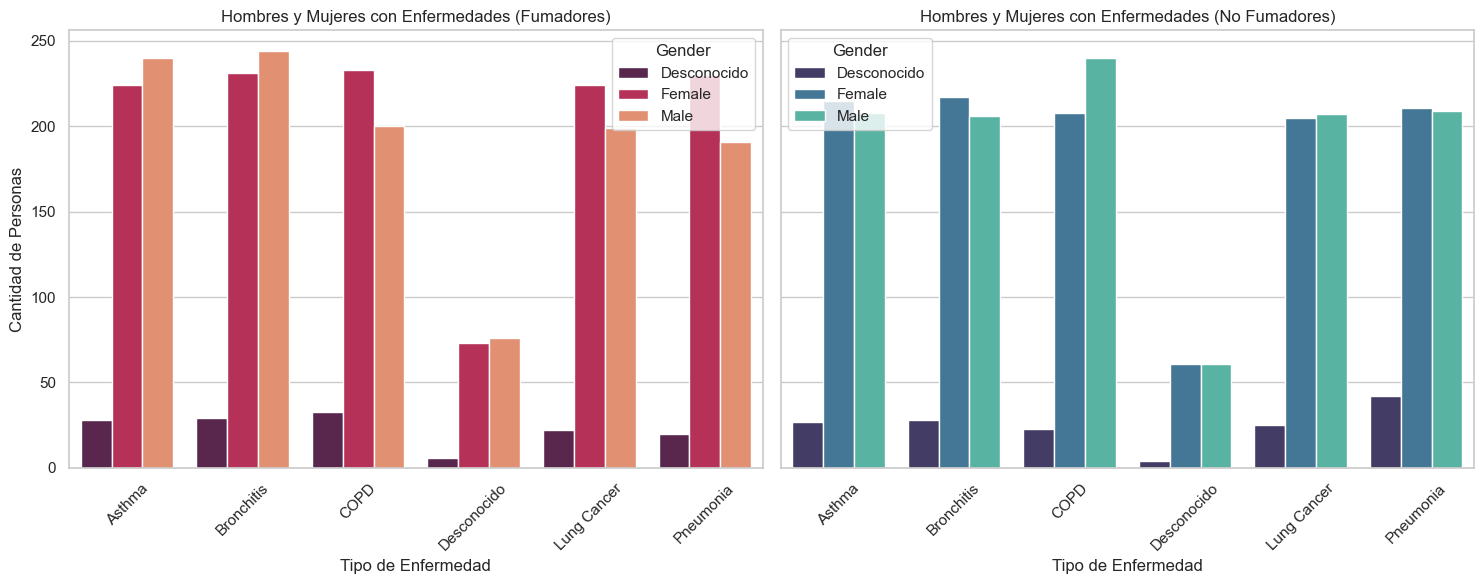

In [6]:
# Filtramos los datos
fumadores = df[df["Smoking Status"] == "Yes"]
no_fumadores = df[df["Smoking Status"] == "No"]

# Agrupamos por género y enfermedad
fumadores_grouped = fumadores.groupby(["Disease Type", "Gender"]).size().reset_index(name="count")
no_fumadores_grouped = no_fumadores.groupby(["Disease Type", "Gender"]).size().reset_index(name="count")

# Creamos las gráficas
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Gráfico de fumadores
sns.barplot(
    data=fumadores_grouped, x="Disease Type", y="count", hue="Gender", palette="rocket", ax=axes[0]
)
axes[0].set_title("Hombres y Mujeres con Enfermedades (Fumadores)")
axes[0].set_xlabel("Tipo de Enfermedad")
axes[0].set_ylabel("Cantidad de Personas")
axes[0].tick_params(axis='x', rotation=45)

# Gráfico de no fumadores
sns.barplot(
    data=no_fumadores_grouped, x="Disease Type", y="count", hue="Gender", palette="mako", ax=axes[1]
)
axes[1].set_title("Hombres y Mujeres con Enfermedades (No Fumadores)")
axes[1].set_xlabel("Tipo de Enfermedad")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout() # Ajusta los gráficos para que no se monten
plt.show()

# Edad y Capacidad Pulmonar
- Aquí necesitamos visualizar cómo varía la capacidad pulmonar según la edad.

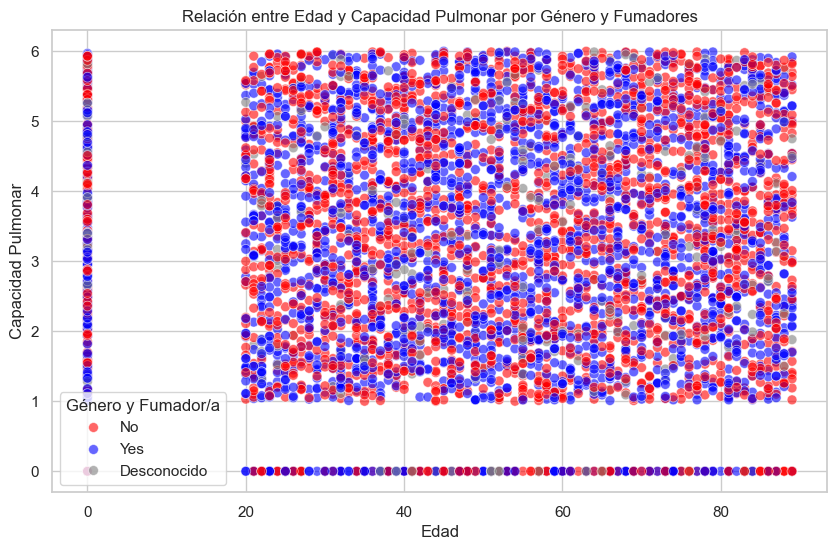

In [7]:
plt.figure(figsize=(10, 6))

# Scatter plot con diferenciación por fumadores y no fumadores
sns.scatterplot(
    data=df, x="Age", y="Lung Capacity", hue="Smoking Status", palette=["red", "blue", "gray"], s=50, alpha=0.6
)

# Configuración del gráfico
plt.title("Relación entre Edad y Capacidad Pulmonar por Género y Fumadores")
plt.xlabel("Edad")
plt.ylabel("Capacidad Pulmonar")
plt.legend(title="Género y Fumador/a")
plt.grid(True)
plt.show()

# Tratamiento, medicamento y cirugías por enfermedad
- Primer gráfico: Muestra la cantidad de tratamientos, medicamentos y cirugías por enfermedad para fumadores.
- Segundo gráfico: Muestra lo mismo pero para no fumadores.

<Figure size 1200x600 with 0 Axes>

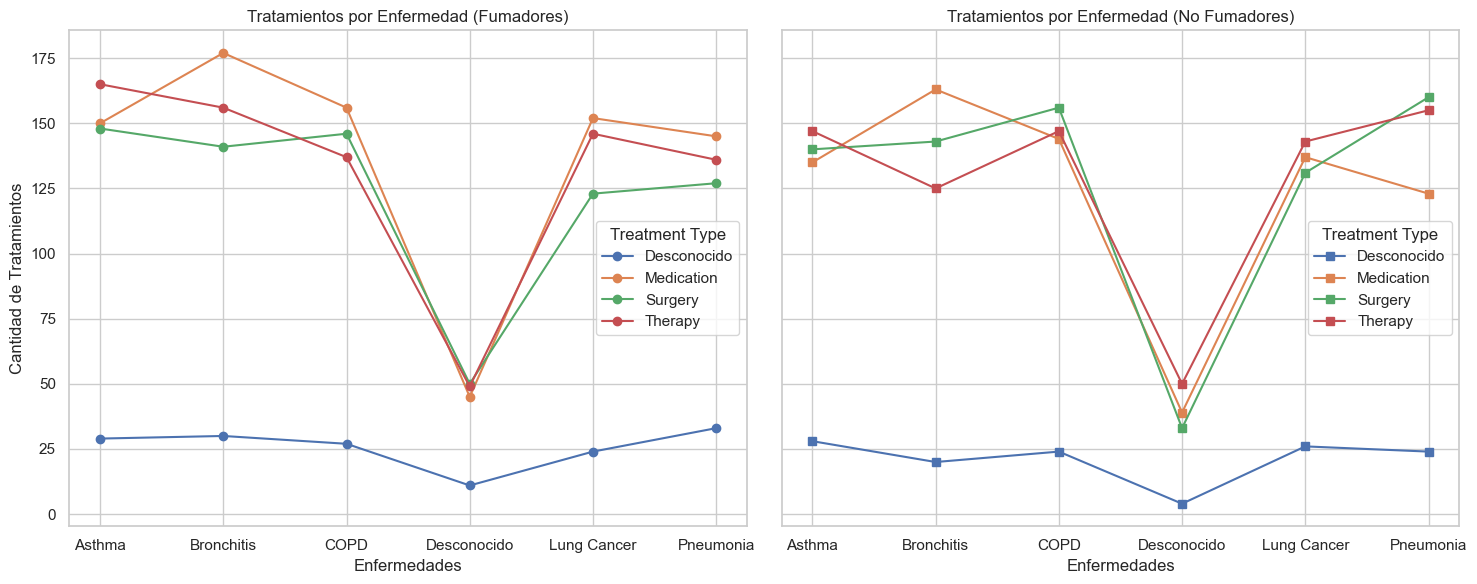

In [8]:
plt.figure(figsize=(12, 6))

# Filtrar datos para fumadores y no fumadores
fumadores = df[df["Smoking Status"] == "Yes"]
no_fumadores = df[df["Smoking Status"] == "No"]

# Contar la cantidad de tratamientos por enfermedad
tratamientos_fumadores = fumadores.groupby(["Disease Type", "Treatment Type"]).size().unstack()
tratamientos_no_fumadores = no_fumadores.groupby(["Disease Type", "Treatment Type"]).size().unstack()

# Crear gráficos en dos subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Gráfico para fumadores
tratamientos_fumadores.plot(kind="line", marker="o", ax=axes[0], title="Tratamientos por Enfermedad (Fumadores)")
axes[0].set_xlabel("Enfermedades")
axes[0].set_ylabel("Cantidad de Tratamientos")
axes[0].grid(True)

# Gráfico para no fumadores
tratamientos_no_fumadores.plot(kind="line", marker="s", ax=axes[1], title="Tratamientos por Enfermedad (No Fumadores)")
axes[1].set_xlabel("Enfermedades")
axes[1].grid(True)

plt.tight_layout()
plt.show()